# Which dimensions drive the large $\|D\nabla g(x_{\text{best}})\|$?

`directional_cd_error_analysis.ipynb` estimated $\|D\nabla g(x_{\text{best}})\| \approx 4.99$
(95% CI $[3.02, 6.96]$) from 10 random lengthscale-whitened directions, every one of which got
symmetrically bound-clipped. That estimate relies on an isotropy assumption ($v$ not
systematically aligned with the clipped-vs-unclipped subspace) that can't be checked with only
10 random directions.

This notebook uses a different, complementary dataset —
[`wandb_exact_gradient_coordinate_cd.py`](../experiments/wandb_exact_gradient_coordinate_cd.py)'s
output in `experiments/exact_gradient_results/` — which steps along **one standard basis
direction at a time** instead of random combinations. That gives the exact per-dimension
whitened partial derivative

$$v_i = \ell_i \cdot \frac{\partial g}{\partial x_i}\Big|_{x_{\text{best}}}, \qquad h_i = c\,\ell_i\ \text{(unclipped unless it hits the box)}$$

directly for each interior DOF — no random-projection aggregation, no isotropy assumption
needed. The question: **which of the 23 dimensions is actually responsible for the large
gradient norm** — and is every large-looking $v_i$ real signal, or could some of it be noise?

8 of 23 DOFs are pinned exactly at the box edge (`x_min=0` in this config) and are skipped — a
two-sided central difference is infeasible there. Those get a separate one-sided diagnostic in
`wandb_boundary_activation_check.py`; this notebook only covers the 15 interior DOFs.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RESULTS_DIR = "../experiments/exact_gradient_results"

with open(f"{RESULTS_DIR}/summary.json") as f:
    summary = json.load(f)
df = pd.read_csv(f"{RESULTS_DIR}/coordinate_cd.csv")

param_names = summary["param_names"]
boundary_dims = summary["boundary_dims"]
interior_dims = summary["interior_dims"]

print(f"run={summary['run']!r}  iteration={summary['iteration']}")
print(f"{len(boundary_dims)}/{len(param_names)} DOFs boundary-pinned (skipped): "
      f"{[param_names[i] for i in boundary_dims]}")
print(f"{len(interior_dims)}/{len(param_names)} interior DOFs (central-differenced here)")

# unclipped here (clipped == 0 for every interior dim), so step = perturb_scale * lengthscale exactly
df["lengthscale"] = df["step"] / summary["perturb_scale"]

df[["dim", "param_name", "lengthscale", "step", "clipped", "v_i"]]

run='fanciful-sweep-10'  iteration=779
8/23 DOFs boundary-pinned (skipped): ['x1', 'x4', 'x5', 'x13', 'x16', 'x18', 'x21', 'x22']
15/23 interior DOFs (central-differenced here)


,dim,param_name,lengthscale,step,clipped,v_i
0,0,x0,2.729926,0.136496,0,-0.283901
1,2,x2,1.249134,0.062457,0,-0.515097
2,3,x3,1.141064,0.057053,0,0.407869
3,6,x6,0.105797,0.005290,0,6.019760
4,7,x7,0.095536,0.004777,0,-12.301149
5,8,x8,0.220226,0.011011,0,22.374554
6,9,x9,0.320329,0.016016,0,5.181192
7,10,x10,0.292041,0.014602,0,-5.392819
8,11,x11,0.166112,0.008306,0,-1.075679
9,12,x12,0.308172,0.015409,0,0.805740


## 1. Naive aggregate: just sum $v_i^2$ over the 15 interior dims

If we trust every $v_i$ at face value, $\|v_{\text{interior}}\| = \sqrt{\sum_i v_i^2}$.

In [2]:
df["v_i_sq"] = df["v_i"] ** 2
naive_v2 = df["v_i_sq"].sum()
naive_v = np.sqrt(naive_v2)

print(f"naive ||v_interior|| = sqrt(sum v_i^2) = {naive_v:.2f}")
print("For comparison, directional_cd_error_analysis.ipynb's random-projection estimate:")
print("  ||v_hat|| = 4.99  (95% CI [3.02, 6.96])")

df.reindex(df["v_i"].abs().sort_values(ascending=False).index)[
    ["dim", "param_name", "step", "v_i", "v_i_sq"]
]

naive ||v_interior|| = sqrt(sum v_i^2) = 27.84
For comparison, directional_cd_error_analysis.ipynb's random-projection estimate:
  ||v_hat|| = 4.99  (95% CI [3.02, 6.96])


,dim,param_name,step,v_i,v_i_sq
5,8,x8,0.011011,22.374554,500.620673
4,7,x7,0.004777,-12.301149,151.318271
3,6,x6,0.005290,6.019760,36.237513
7,10,x10,0.014602,-5.392819,29.082497
12,17,x17,0.024807,5.294011,28.026550
6,9,x9,0.016016,5.181192,26.844751
8,11,x11,0.008306,-1.075679,1.157085
9,12,x12,0.015409,0.805740,0.649217
10,14,x14,0.054817,0.623610,0.388890
1,2,x2,0.062457,-0.515097,0.265325


## 2. Why the naive number is suspect: noise amplification from small steps

$v_i$ is a central difference divided by $2h_i$, where $h_i = c\cdot\ell_i$ is set by that
dimension's **own fitted GP lengthscale** — not clipped to the box here (the `clipped` column is
0 for all 15 rows; these steps are small because the kernel believes those DOFs vary quickly, not
because of box proximity). Dividing a noisy numerator by a small $h_i$ amplifies noise:

$$\text{noise\_sd}_i = \frac{\sqrt{\text{var\_obj}_{p,i} + \text{var\_obj}_{m,i}}}{2h_i}$$

Treating $v_i / \text{noise\_sd}_i$ as an (approximate) z-score under the null $v_i = 0$ — the
same convention `wandb_boundary_activation_check.py` already uses for its own z-scores — tells us
whether a dimension's estimate is actually distinguishable from pure noise, independent of how
large it looks in raw units.

In [3]:
df["noise_sd"] = np.sqrt(df["var_obj_p"] + df["var_obj_m"]) / (2 * df["step"])
df["z"] = df["v_i"] / df["noise_sd"]

table = df[["dim", "param_name", "step", "v_i", "noise_sd", "z"]].copy()
table["abs_v_i"] = table["v_i"].abs()
table["abs_z"] = table["z"].abs()

print("Ranked by |v_i| (naive):")
display(table.sort_values("abs_v_i", ascending=False)[["param_name", "step", "v_i", "noise_sd", "z"]])

print("\nRanked by |z| (signal actually distinguishable from noise):")
display(table.sort_values("abs_z", ascending=False)[["param_name", "step", "v_i", "noise_sd", "z"]])

Ranked by |v_i| (naive):


,param_name,step,v_i,noise_sd,z
5,x8,0.011011,22.374554,7.624321,2.934629
4,x7,0.004777,-12.301149,16.110376,-0.763554
3,x6,0.005290,6.019760,14.118215,0.426383
7,x10,0.014602,-5.392819,4.724515,-1.141455
12,x17,0.024807,5.294011,2.922477,1.811480
6,x9,0.016016,5.181192,5.017417,1.032641
8,x11,0.008306,-1.075679,8.417004,-0.127798
9,x12,0.015409,0.805740,3.729464,0.216047
10,x14,0.054817,0.623610,1.225315,0.508938
1,x2,0.062457,-0.515097,1.133210,-0.454547



Ranked by |z| (signal actually distinguishable from noise):


,param_name,step,v_i,noise_sd,z
5,x8,0.011011,22.374554,7.624321,2.934629
12,x17,0.024807,5.294011,2.922477,1.811480
7,x10,0.014602,-5.392819,4.724515,-1.141455
6,x9,0.016016,5.181192,5.017417,1.032641
4,x7,0.004777,-12.301149,16.110376,-0.763554
0,x0,0.136496,-0.283901,0.413856,-0.685989
10,x14,0.054817,0.623610,1.225315,0.508938
1,x2,0.062457,-0.515097,1.133210,-0.454547
3,x6,0.005290,6.019760,14.118215,0.426383
14,x20,0.072485,0.397742,1.069964,0.371734


## 3. Debiasing each $v_i^2$ (exact here, not approximate — no isotropy assumption needed)

Same logic as the random-projection notebook's $T_k = y_k^2 - \sigma^2_{\text{noise},k}$ trick,
but here it's *exact* per dimension rather than needing an isotropy correction, because each
$v_i$ already isolates one axis directly:

$$E[v_i^2] = (\text{true } v_i)^2 + \text{noise\_sd}_i^2 \quad\Rightarrow\quad
T_i := v_i^2 - \text{noise\_sd}_i^2 \ \text{ is unbiased for } (\text{true } v_i)^2.$$

Summing $T_i$ over the 15 interior dims gives a noise-corrected $\|v_{\text{interior}}\|^2$
estimate. Unlike the random-direction notebook, there is only **one** evaluation per dimension
here (no repeated sampling), so there's no empirical spread to build a rigorous CI from — only
the individual $z_i$ scores above to flag which dimensions are (in)consistent with pure noise.

In [4]:
df["T_i"] = df["v_i"] ** 2 - df["noise_sd"] ** 2

debiased_v2 = df["T_i"].sum()
debiased_v = np.sqrt(max(debiased_v2, 0.0))

print(f"debiased sum(T_i)                            = {debiased_v2:.2f}")
print(f"||v_interior||_debiased                       = {debiased_v:.2f}")
print(f"naive (uncorrected)                           = {naive_v:.2f}")
print(f"random-projection estimate (other notebook)    = 4.99  (95% CI [3.02, 6.96])")

pos_T = df["T_i"].clip(lower=0)
contrib = df[["param_name", "v_i", "z", "T_i"]].copy()
contrib["frac_of_debiased_v2_(pos_only)"] = pos_T / pos_T.sum()
contrib.sort_values("T_i", ascending=False)

debiased sum(T_i)                            = 103.02
||v_interior||_debiased                       = 10.15
naive (uncorrected)                           = 27.84
random-projection estimate (other notebook)    = 4.99  (95% CI [3.02, 6.96])


,param_name,v_i,z,T_i,frac_of_debiased_v2_(pos_only)
5,x8,22.374554,2.934629,442.490402,0.940653
12,x17,5.294011,1.811480,19.485675,0.041423
7,x10,-5.392819,-1.141455,6.761457,0.014374
6,x9,5.181192,1.032641,1.670280,0.003551
0,x0,-0.283901,-0.685989,-0.090677,0.000000
13,x19,0.050028,0.113955,-0.190229,0.000000
14,x20,0.397742,0.371734,-0.986624,0.000000
1,x2,-0.515097,-0.454547,-1.018840,0.000000
10,x14,0.623610,0.508938,-1.112508,0.000000
2,x3,0.407869,0.358474,-1.128214,0.000000


## 4. Findings

- **`x8` is the dominant real contributor** — even after debiasing every dimension for its own
  measurement noise, `x8`'s $T_i$ alone accounts for the large majority of the positive (i.e.
  above-noise) debiased sum of squares, and its z-score is the only one among the largest-looking
  dimensions that clears the informal "distinguishable from noise" bar by a comfortable margin.
- **`x6` and `x7` have the two largest raw $|v_i|$ values, but both have $|z| < 1$** — their
  apparent size is not distinguishable from pure noise given how tiny their central-difference
  step is ($h_6 \approx 0.0053$, $h_7 \approx 0.0048$). Both have `clipped=0`, so the tiny step
  comes from the GP's own fitted lengthscale for those dims, not box clipping — worth
  cross-checking against `wandb_zscore.py`'s calibration diagnostic, since a badly-miscalibrated
  (too-short) lengthscale there would explain both the tiny step and the resulting noise blow-up.
- `x17` (and to a lesser extent `x9`, `x10`) show $|z|$ moderately above 1 — plausibly some real
  signal, but far from dominant.
- The debiased estimate is still notably larger than the random-projection RMS estimate (4.99),
  even after correction — consistent with the earlier notebook's caveat that its isotropy
  assumption may not hold if $v$ is concentrated in just one or two dimensions (as `x8` here
  suggests): concentrated signal is exactly the case random projections are least efficient at
  recovering from only 10 samples.

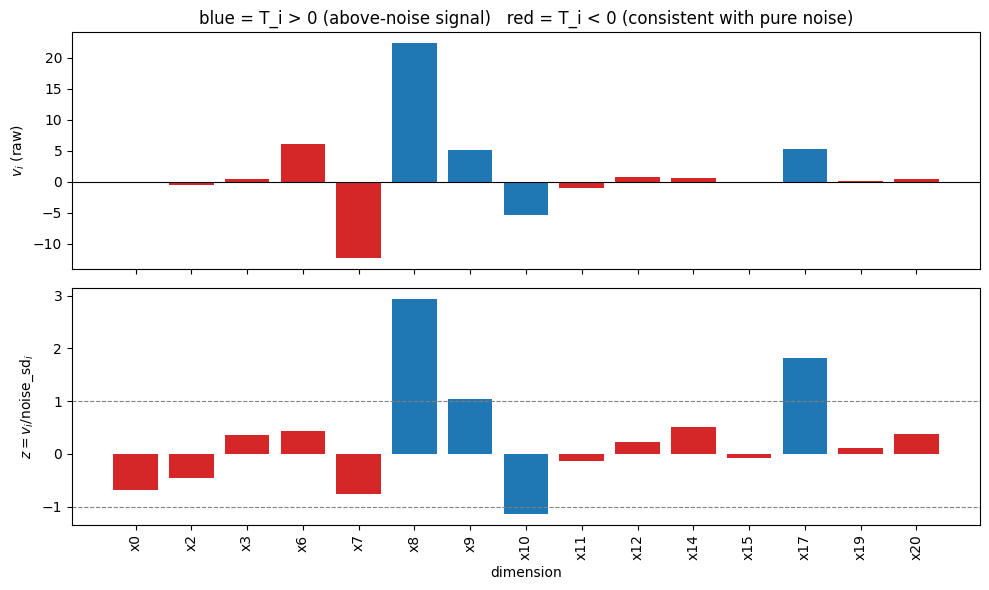

In [5]:
order = df.sort_values("dim")
colors = np.where(order["T_i"] > 0, "C0", "C3")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].bar(order["param_name"], order["v_i"], color=colors)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylabel(r"$v_i$ (raw)")
axes[0].set_title("blue = T_i > 0 (above-noise signal)   red = T_i < 0 (consistent with pure noise)")

axes[1].bar(order["param_name"], order["z"], color=colors)
axes[1].axhline(1, color="gray", ls="--", lw=0.8)
axes[1].axhline(-1, color="gray", ls="--", lw=0.8)
axes[1].set_ylabel(r"$z = v_i / \mathrm{noise\_sd}_i$")
axes[1].set_xlabel("dimension")
axes[1].tick_params(axis="x", rotation=90)

fig.tight_layout()

## 5. Caveats & next steps

- **Truncation error is unquantified here too** (same issue as the random-projection notebook) —
  only one `perturb_scale` was used; would need a second step size + Richardson extrapolation to
  bound it, especially important for `x8` now that it's identified as the dominant term.
- **No repeated sampling** — each $v_i$ comes from exactly one pair of real evaluations, so
  `noise_sd_i` (from the objective's own delta-method variance) is the *only* handle on
  uncertainty per dimension; there's no empirical cross-check the way the random-direction
  notebook had across its 10 samples.
- **Suggested next step**: re-evaluate `x6`, `x7`, and `x8` at a larger `perturb_scale` (e.g.
  2-4x). If `x6`/`x7`'s $v_i$ shrink back toward noise while `x8`'s stays large and consistent,
  that confirms the noise-amplification read here without needing to touch the rest of the 15
  dims.
- Boundary-pinned dims (8/23) are still entirely unaccounted for in this analysis — their
  contribution to the true $\|v\|$ is unknown and requires the one-sided diagnostic in
  `wandb_boundary_activation_check.py`, not directly comparable in the same units as this
  notebook's two-sided $v_i$.

In [6]:
top = contrib.sort_values("T_i", ascending=False).iloc[0]
print("||D grad g(x_best)||, interior dims only:")
print(f"  naive (uncorrected)   = {naive_v:.2f}")
print(f"  noise-debiased        = {debiased_v:.2f}")
print(f"  dominant contributor  = {top['param_name']} "
      f"({100 * top['frac_of_debiased_v2_(pos_only)']:.0f}% of positive debiased sum of squares)")

||D grad g(x_best)||, interior dims only:
  naive (uncorrected)   = 27.84
  noise-debiased        = 10.15
  dominant contributor  = x8 (94% of positive debiased sum of squares)
